In [4]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [2]:
np.random.randn()

0.6767333468084116

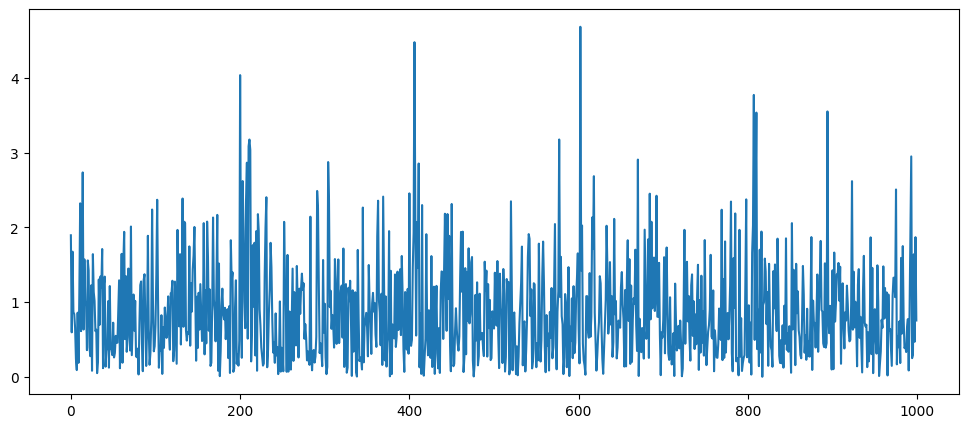

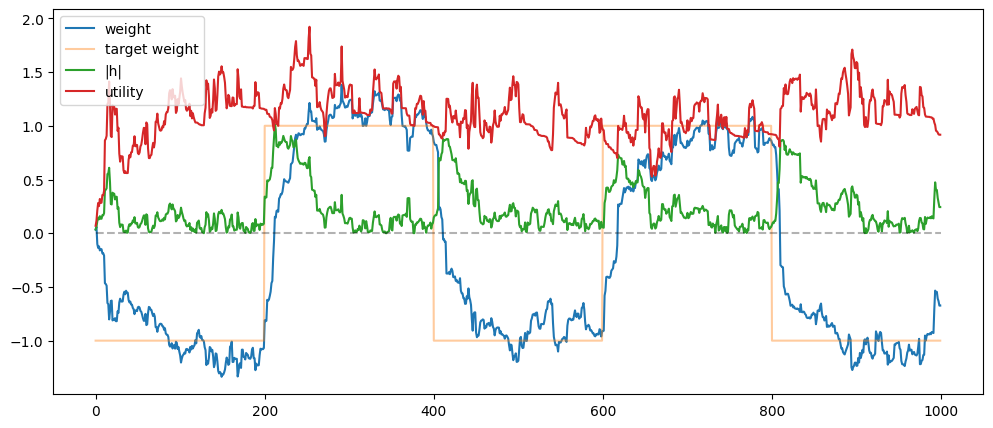

In [ ]:
TRAIN_STEPS = 1000
FLIP_PERIOD = 200

target_weight = 1
step_size = 0.05
weight = 0
h = 0

rmse_history = []
weight_history = []
target_weight_history = []
h_history = []

for step in range(TRAIN_STEPS):
    if step % FLIP_PERIOD == 0:
        target_weight = -target_weight
    
    x = np.random.randn()
    target = target_weight * x + np.random.randn()
    pred = weight * x
    
    error = target - pred
    grad = error * x
    weight += step_size * grad
    h = h * np.maximum(0, 1 - step_size * x**2)  + step_size * error * x
        
    rmse_history.append(np.abs(error))
    weight_history.append(weight)
    target_weight_history.append(target_weight)
    h_history.append(h)


plt.figure(figsize=(12, 5))
plt.plot(rmse_history)
plt.title('Learning Curve')
plt.ylabel('RMSE')
plt.xlabel('step')
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(weight_history, label='weight')
plt.plot(target_weight_history, alpha=0.4, label='target weight')
plt.plot(np.abs(np.array(h_history)), label='|h|')
plt.plot(np.abs(np.array(h_history)) + np.abs(np.array(weight_history)), label='utility')
plt.hlines(0, 0, TRAIN_STEPS, alpha=0.3, linestyle='--', color='black')
plt.xlabel('step')
plt.legend()
plt.show()



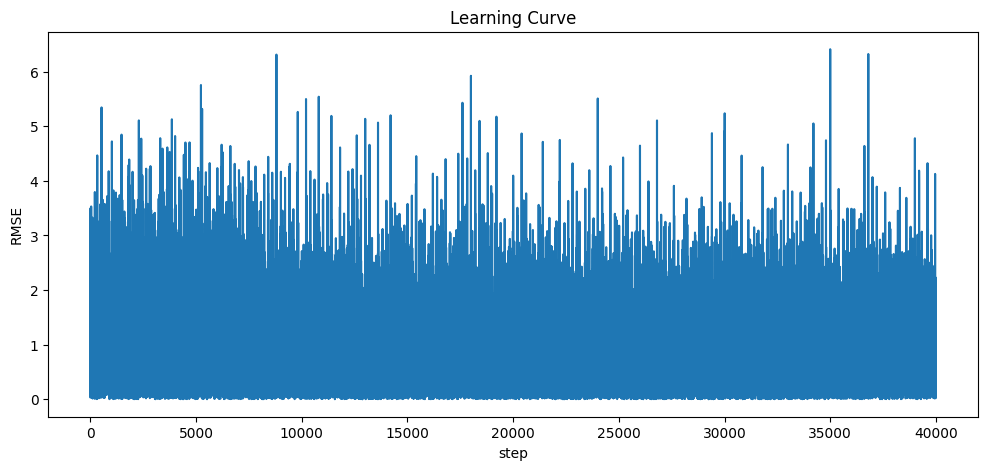

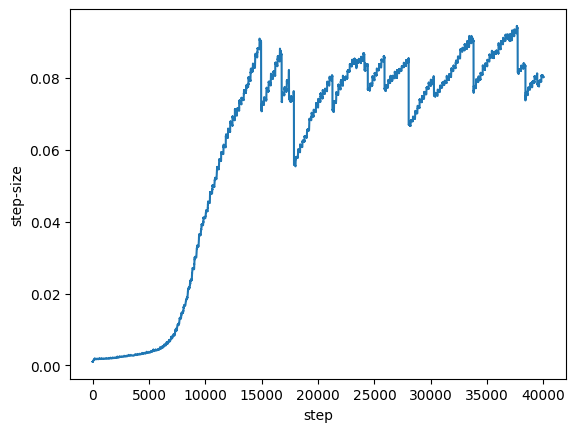

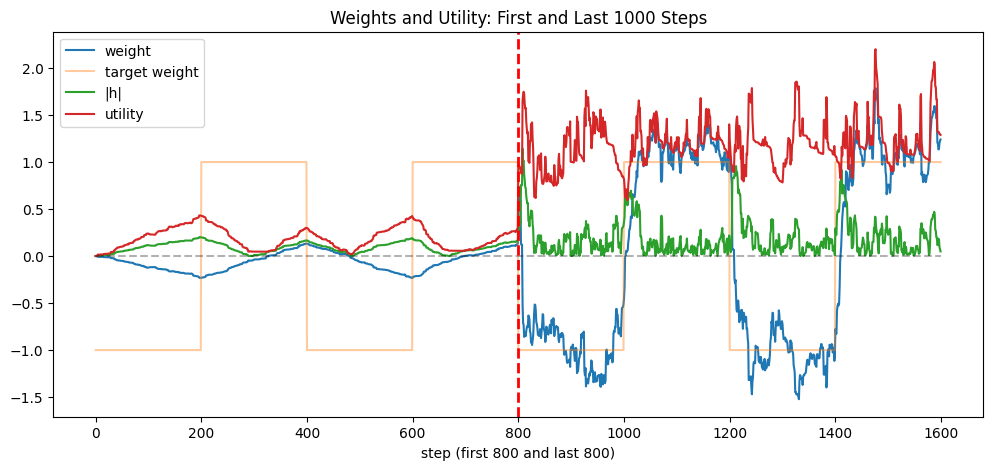

In [81]:
TRAIN_STEPS = 40_000
FLIP_PERIOD = 200

META_STEP_SIZE = 0.02
TAU = 1e4

target_weight = 1
step_size = 0.001
weight = 0
h = 0
v = 0

rmse_history = []
weight_history = []
target_weight_history = []
h_history = []
step_size_history = []

for step in range(TRAIN_STEPS):
    if step % FLIP_PERIOD == 0:
        target_weight = -target_weight
    
    x = np.random.randn()
    target = target_weight * x + np.random.randn()
    pred = weight * x
    
    error = target - pred
    grad = error * x

    # Autostep meta-update
    v = max(abs(grad * h), v + step_size * x**2 / TAU * (abs(grad * h) - v))
    if v != 0:
        step_size *= np.exp(META_STEP_SIZE * grad * h / v)
    step_size /= max(step_size * x**2, 1)

    weight += step_size * grad
    h = h * max(0, 1 - step_size * x**2) + step_size * grad
        
    rmse_history.append(np.abs(error))
    weight_history.append(weight)
    target_weight_history.append(target_weight)
    h_history.append(h)
    step_size_history.append(step_size)

plt.figure(figsize=(12, 5))
plt.plot(rmse_history)
plt.title('Learning Curve')
plt.ylabel('RMSE')
plt.xlabel('step')
plt.show()

plt.plot(step_size_history)
plt.ylabel('step-size')
plt.xlabel('step')
plt.show()

# Define how many steps to show at the start and end
n_display = 800

# Prepare data indices
start_idxs = np.arange(n_display)
end_idxs = np.arange(len(weight_history) - n_display, len(weight_history))
middle_bar = n_display  # The step where start transitions to end in concatenated plot

# Concatenate the two sections for plotting
plot_indices = np.concatenate([start_idxs, end_idxs])
steps_concat = np.arange(2 * n_display)

# Concatenate data for each series
weight_concat = np.concatenate([np.array(weight_history)[start_idxs], np.array(weight_history)[end_idxs]])
target_weight_concat = np.concatenate([np.array(target_weight_history)[start_idxs], np.array(target_weight_history)[end_idxs]])
h_concat = np.concatenate([np.array(h_history)[start_idxs], np.array(h_history)[end_idxs]])
utility_concat = np.abs(h_concat) + np.abs(weight_concat)

plt.figure(figsize=(12, 5))
plt.plot(steps_concat, weight_concat, label='weight')
plt.plot(steps_concat, target_weight_concat, alpha=0.4, label='target weight')
plt.plot(steps_concat, np.abs(h_concat), label='|h|')
plt.plot(steps_concat, utility_concat, label='utility')
plt.hlines(0, 0, 2 * n_display, alpha=0.3, linestyle='--', color='black')
plt.axvline(x=middle_bar, color='red', linestyle='--', linewidth=2.0)  # Vertical bar to separate
plt.xlabel(f'step (first {n_display} and last {n_display})')
plt.legend()
plt.title('Weights and Utility: First and Last 1000 Steps')
plt.show()


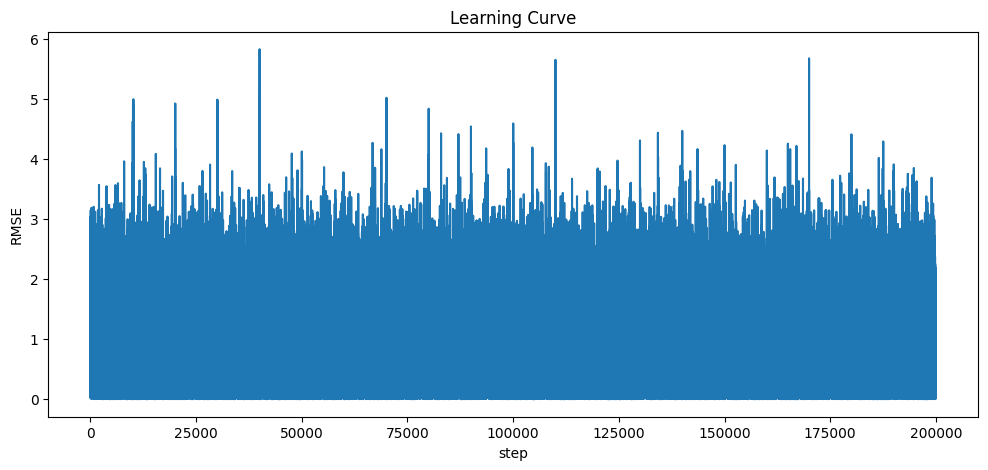

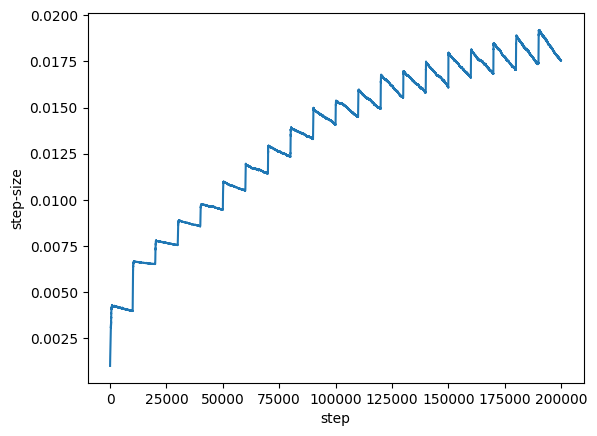

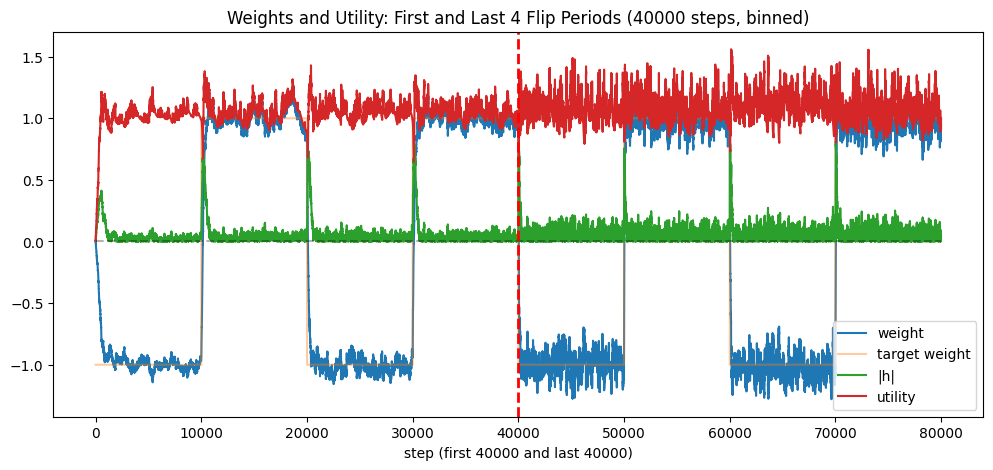

In [92]:
TRAIN_STEPS = 200_000
FLIP_PERIOD = 10_000  # Changed flip period to 2000

META_STEP_SIZE = 0.02
TAU = 1e4

target_weight = 1
step_size = 0.001
weight = 0
h = 0
v = 0

rmse_history = []
weight_history = []
target_weight_history = []
h_history = []
step_size_history = []

for step in range(TRAIN_STEPS):
    if step % FLIP_PERIOD == 0:
        target_weight = -target_weight
    
    x = np.random.randn()
    target = target_weight * x + np.random.randn()
    pred = weight * x
    
    error = target - pred
    grad = error * x

    # Autostep meta-update
    v = max(abs(grad * h), v + step_size * x**2 / TAU * (abs(grad * h) - v))
    if v != 0:
        step_size *= np.exp(META_STEP_SIZE * grad * h / v)
    step_size /= max(step_size * x**2, 1)

    weight += step_size * grad
    h = h * max(0, 1 - step_size * x**2) + step_size * grad
        
    rmse_history.append(np.abs(error))
    weight_history.append(weight)
    target_weight_history.append(target_weight)
    h_history.append(h)
    step_size_history.append(step_size)

BIN = 1  # Bin size for mean averaging

def bin_mean(arr, bin_size=BIN):
    arr = np.array(arr)
    n_bins = len(arr) // bin_size
    arr = arr[:n_bins * bin_size]
    arr_reshaped = arr.reshape(n_bins, bin_size)
    return arr_reshaped.mean(axis=1)

binned_rmse_history = bin_mean(rmse_history)
binned_step_size_history = bin_mean(step_size_history)

plt.figure(figsize=(12, 5))
plt.plot(np.arange(len(binned_rmse_history)) * BIN, binned_rmse_history)
plt.title('Learning Curve')
plt.ylabel('RMSE')
plt.xlabel('step')
plt.show()

plt.plot(np.arange(len(binned_step_size_history)) * BIN, binned_step_size_history)
plt.ylabel('step-size')
plt.xlabel('step')
plt.show()

# --- New logic below to make displayed regions exactly 4 flip periods each at start and end ---

flips_to_show = 4
steps_per_flip = FLIP_PERIOD
display_steps = flips_to_show * steps_per_flip

# Convert to binned space
start_idxs = np.arange(display_steps // BIN)
end_idxs = np.arange((len(weight_history) // BIN) - (display_steps // BIN), len(weight_history) // BIN)
bin_n_display = display_steps // BIN
middle_bar = bin_n_display  # Where start transitions to end in concatenated plot

def get_binned_concat(arr):
    arr = np.array(arr)
    n_bins = len(arr) // BIN
    arr = arr[:n_bins*BIN].reshape(n_bins, BIN).mean(axis=1)
    return np.concatenate([arr[start_idxs], arr[end_idxs]])

weight_concat = get_binned_concat(weight_history)
target_weight_concat = get_binned_concat(target_weight_history)
h_concat = get_binned_concat(h_history)
utility_concat = np.abs(h_concat) + np.abs(weight_concat)
steps_concat = np.arange(2 * bin_n_display) * BIN

plt.figure(figsize=(12, 5))
plt.plot(steps_concat, weight_concat, label='weight')
plt.plot(steps_concat, target_weight_concat, alpha=0.4, label='target weight')
plt.plot(steps_concat, np.abs(h_concat), label='|h|')
plt.plot(steps_concat, utility_concat, label='utility')
plt.hlines(0, 0, 2 * bin_n_display, alpha=0.3, linestyle='--', color='black')
plt.axvline(x=middle_bar * BIN, color='red', linestyle='--', linewidth=2.0)  # Vertical bar to separate
plt.xlabel(f'step (first {display_steps} and last {display_steps})')
plt.legend()
plt.title(f'Weights and Utility: First and Last {flips_to_show} Flip Periods ({display_steps} steps, binned)')
plt.show()
